
# 合并训练 Notebook（8 个模型全量版）

这份 Notebook 使用 Excel 文件 `零维表格转换 (2).xlsx` 中的两个 sheet 共同训练：

- `对应优化质量`
- `丝阵质量20_30_40mgcm`

本 Notebook 统一放入 8 个模型：

1. `PowerLaw`
2. `Poly2Ridge`
3. `KNN`
4. `MLP`
5. `RandomForest`
6. `LightGBM`
7. `XGBoost`
8. `CatBoost`

说明：
- 这里的目标仍然是预测动能 `E`，再由 `E + m` 反算速度 `v`。
- 数据划分沿用当前项目的固定口径：`70% train + 15% val + 15% test`，最终评估时使用 `train + val` 合并训练，并在固定 `test` 上测分。
- 损失曲线只对“有显式迭代训练过程”的模型绘制：`MLP / LightGBM / XGBoost / CatBoost`。
- `PowerLaw / Poly2Ridge / KNN / RandomForest` 不属于逐轮迭代优化模型，因此没有逐 epoch 的损失折线图。


In [1]:

# 导入基础库。
import json
from pathlib import Path

# 导入数值、表格和绘图库。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 导入提升树和集成模型。
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# 从现有脚本中复用已经验证过的数据读取、修复和切分函数。
from train_missing_models_on_xlsx import (
    read_sheet_as_base_dataset,
    repair_velocity_values,
    train_val_test_split,
    XLSX_PATH,
    SOURCE_SHEET,
    TARGET_SHEET,
)

# 从现有代理模型脚本中复用特征工程、评估函数和 4 个基础模型定义。
from train_zpinch_surrogate import (
    make_features,
    evaluate_model,
    PowerLawModel,
    Poly2RidgeModel,
    KNNRegressorModel,
    MLP2LayerModel,
)

# 定义当前 Notebook 根目录和输出目录。
ROOT_DIR = Path('/home/user/zpinch10000')
OUTPUT_DIR = ROOT_DIR / 'ai_xlsx_all_in_training_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 固定随机种子，保证 Notebook 每次执行时尽量复现同一划分。
SEED = 2026

print('ROOT_DIR =', ROOT_DIR)
print('OUTPUT_DIR =', OUTPUT_DIR)
print('XLSX_PATH =', XLSX_PATH)
print('SOURCE_SHEET =', SOURCE_SHEET)
print('TARGET_SHEET =', TARGET_SHEET)


ROOT_DIR = /home/user/zpinch10000
OUTPUT_DIR = /home/user/zpinch10000/ai_xlsx_all_in_training_outputs
XLSX_PATH = /home/user/zpinch_package_20260306/零维表格转换 (2).xlsx
SOURCE_SHEET = 对应优化质量
TARGET_SHEET = 丝阵质量20_30_40mgcm


In [2]:

# 读取两个 sheet 的基础数据。
# X_base 的原始列顺序是：I, tr, liner_r, foam_r, m, Z。
source_df, Xs_base, yEs, yvs_raw = read_sheet_as_base_dataset(XLSX_PATH, SOURCE_SHEET)
target_df, Xt_base, yEt, yvt_raw = read_sheet_as_base_dataset(XLSX_PATH, TARGET_SHEET)

# 对速度列做修复，避免旧文档/转换过程中的科学计数法断裂影响训练。
yvs, repaired_source = repair_velocity_values(Xs_base, yEs, yvs_raw)
yvt, repaired_target = repair_velocity_values(Xt_base, yEt, yvt_raw)

# 合并两个来源的数据，并保留来源标签，方便后续在同一个测试集里分别统计 source/target 子集指标。
X_base = np.vstack([Xs_base, Xt_base])
yE = np.concatenate([yEs, yEt])
yv = np.concatenate([yvs, yvt])
domain = np.array(['source'] * len(Xs_base) + ['target'] * len(Xt_base))

# 调用现有特征工程，得到真正用于建模的特征矩阵。
X, feat_names = make_features(X_base)

# 打印最基础的数据规模，确认本次 Notebook 用到的是 10944 条合并样本。
print('source rows =', len(Xs_base))
print('target rows =', len(Xt_base))
print('combined rows =', len(X))
print('repaired source velocity rows =', repaired_source)
print('repaired target velocity rows =', repaired_target)
print('feature count =', len(feat_names))

# 简单查看特征名，确认质量 m 仍然作为输入特征进入模型。
feat_names


source rows = 2736
target rows = 8208
combined rows = 10944
repaired source velocity rows = 0
repaired target velocity rows = 0
feature count = 14


['I_MA',
 'tr_ns',
 'liner_r_cm',
 'foam_r_cm',
 'm_mg_per_cm',
 'Z_atomic_number',
 'ratio_foam_liner',
 'gap_r_cm',
 'area_diff_cm2',
 'drive_proxy_I_over_tr',
 'I_mul_liner',
 'I_mul_foam',
 'tr_mul_liner',
 'tr_mul_foam']

In [3]:

# 按固定随机种子切分 train / val / test。
# 这里先得到 70% train、15% val、15% test。
tr_idx, va_idx, te_idx = train_val_test_split(len(X), seed=SEED)

# 准备训练、验证和测试集合。
Xtr, ytr = X[tr_idx], yE[tr_idx]
Xva, yva = X[va_idx], yE[va_idx]
Xte, yte = X[te_idx], yE[te_idx]
vte = yv[te_idx]
mte = Xte[:, 4]
dte = domain[te_idx]

# 最终固定测试时，会把 train 和 val 合并在一起重新训练模型。
train_idx = np.concatenate([tr_idx, va_idx])

print('train size =', len(tr_idx))
print('val size =', len(va_idx))
print('test size =', len(te_idx))
print('final train+val size =', len(train_idx))
print('source rows in fixed test split =', int((dte == 'source').sum()))
print('target rows in fixed test split =', int((dte == 'target').sum()))


train size = 7660
val size = 1641
test size = 1643
final train+val size = 9301
source rows in fixed test split = 407
target rows in fixed test split = 1236


In [4]:

# 定义 Notebook 中使用的全部 8 个模型。
# 前 4 个模型来自项目原始代理模型脚本，后 4 个是后续补充的树模型/提升树模型。
def build_all_models():
    return {
        'PowerLaw': PowerLawModel(),
        'Poly2Ridge': Poly2RidgeModel(alpha=1e-2),
        'KNN': KNNRegressorModel(k=8),
        'MLP': MLP2LayerModel(h1=64, h2=32, lr=1e-3, epochs=220, seed=42),
        'RandomForest': RandomForestRegressor(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
        ),
        'LightGBM': LGBMRegressor(
            random_state=42,
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            verbose=-1,
        ),
        'XGBoost': XGBRegressor(
            random_state=42,
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            tree_method='hist',
            n_jobs=-1,
            verbosity=0,
        ),
        'CatBoost': CatBoostRegressor(
            random_seed=42,
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function='RMSE',
            verbose=False,
        ),
    }

all_models = build_all_models()
print('all model names =', list(all_models.keys()))


all model names = ['PowerLaw', 'Poly2Ridge', 'KNN', 'MLP', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']



## 八种方法的数学公式与通俗解释

下面这 8 个方法都在做同一件事：给定输入特征 `x`，预测动能 `E`。区别在于“它们怎样把输入映射到输出”。

### 1. PowerLaw

数学形式：

\[
\log \hat{E} = b_0 + \sum_i b_i \log(x_i + s_i)
\]

等价写法：

\[
\hat{E} = \exp(b_0) \prod_i (x_i + s_i)^{b_i}
\]

通俗解释：
- 它假设输出和输入之间更像“幂次关系”。
- 如果某个输入增大到原来的 `p` 倍，输出大约会按 `p^{b_i}` 的比例变化。
- 这种模型结构简单、可解释性强，但表达复杂非线性关系的能力有限。

### 2. Poly2Ridge

数学形式：

\[
\hat{E} = w_0 + \sum_i w_i z_i + \sum_i w_{ii} z_i^2 + \sum_{i<j} w_{ij} z_i z_j
\]

其中 `z_i` 是标准化后的特征。训练时优化的是：

\[
\min_w \|y - Xw\|^2 + \alpha \|w\|^2
\]

通俗解释：
- 它会显式加入平方项和交叉项，所以能表达“弯曲关系”和“两个变量一起作用”的关系。
- `Ridge` 正则项的作用是防止系数过大，降低过拟合。
- 可以把它理解成“带防抖的二阶多项式回归”。

### 3. KNN

数学形式：

\[
\hat{E}(x) = \frac{\sum_{i \in \mathcal{N}_k(x)} w_i E_i}{\sum_{i \in \mathcal{N}_k(x)} w_i}, \quad
w_i = \frac{1}{\max(d(x, x_i), \varepsilon)}
\]

通俗解释：
- 它不先学一个全局公式，而是“看离当前样本最近的 k 个历史样本”。
- 离得越近，权重越大。
- 这个方法对局部插值常常有效，但一旦遇到没见过的区域，容易失稳。

### 4. MLP

数学形式：

\[
\hat{E}(x) = W_3 \sigma(W_2 \sigma(W_1 x + b_1) + b_2) + b_3
\]

其中 `\sigma(\cdot)` 是 ReLU 激活函数。训练目标是最小化均方误差：

\[
\mathcal{L} = \frac{1}{n} \sum_{j=1}^{n} (\hat{E}_j - E_j)^2
\]

参数更新使用 Adam。

通俗解释：
- 它本质上是两层非线性变换，可以学到更复杂的弯曲关系。
- 优点是表达能力强。
- 缺点是训练更慢，对样本规模和分布更敏感。

### 5. RandomForest

数学形式：

\[
\hat{E}(x) = \frac{1}{T} \sum_{t=1}^{T} f_t(x)
\]

其中 `f_t(x)` 表示第 `t` 棵回归树的输出。

通俗解释：
- 它会训练很多棵树，每棵树都在不同随机样本、不同随机特征上学习。
- 最后取平均，降低单棵树过拟合的风险。
- 可以理解成“很多棵树投票后取均值”。

### 6. LightGBM

数学形式（提升树共同框架）：

\[
F_M(x) = \sum_{m=1}^{M} \eta h_m(x)
\]

也就是一轮一轮加树，每一轮都去修正前一轮还没学好的残差。

通俗解释：
- LightGBM 也是树模型，但不是“并排很多棵树平均”，而是“后一棵树专门修前一棵树的错”。
- 它用直方图分桶和 leaf-wise 生长策略，速度快、表达力强。

### 7. XGBoost

数学形式同样是加法提升：

\[
F_M(x) = \sum_{m=1}^{M} \eta h_m(x)
\]

但它在每一轮构树时会显式优化带正则的目标函数，并使用二阶近似。

通俗解释：
- 它和 LightGBM 一样属于 boosting 树。
- 差别在于实现细节、目标优化方式和树的构造策略。
- 常见特点是稳、强，但调参空间也更大。

### 8. CatBoost

数学形式本质上仍然是提升树：

\[
F_M(x) = \sum_{m=1}^{M} \eta h_m(x)
\]

通俗解释：
- CatBoost 的核心优势通常在类别特征处理和 ordered boosting。
- 这次数据里特征基本都是数值型，所以它的优势没有被完全发挥出来。
- 但它仍然是一个很强的 boosting 模型。



## 训练过程是怎么循环的

可以把这份 notebook 的训练流程理解成三层循环。

### 第一层：数据层面的固定切分

当前固定划分是：

- `train = 7660`
- `val = 1641`
- `test = 1643`

流程是：

1. 先用 `train` 训练模型
2. 可迭代模型在训练时顺带观察 `val`
3. 最终正式评估时，把 `train + val = 9301` 合并起来重新训练
4. 只在 `test = 1643` 上打分

所以测试集在最终打分前是完全不参与训练的。

### 第二层：模型之间的外层循环

Notebook 里本质上在做这件事：

```python
for model in all_models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = evaluate_model(y_test, pred, m_test, v_test)
```

也就是说：

- 先训 `PowerLaw`
- 再训 `Poly2Ridge`
- 再训 `KNN`
- 再训 `MLP`
- 再训 `RandomForest`
- 再训 `LightGBM`
- 再训 `XGBoost`
- 再训 `CatBoost`

最后把 8 个模型的分数放到同一张表里比较。

### 第三层：每个模型内部自己的循环方式

#### 1. PowerLaw / Poly2Ridge

这两类模型没有很多轮 epoch。

它们更像是：
- 先把特征变换好
- 再一次性解出一组系数
- 然后直接得到预测函数

所以它们的“循环”主要不是很多轮训练，而是一次矩阵求解。

#### 2. KNN

KNN 训练时也几乎没有“很多轮更新参数”。

它做的是：
- 先把训练集保存下来
- 预测新样本时，再去找最近的 `k=8` 个邻居
- 按距离加权平均得到预测值

所以 KNN 慢的地方不在训练，而在预测阶段的距离计算。

#### 3. MLP

MLP 的内部循环最像大家平时理解的“训练很多轮”：

```python
for epoch in range(220):
    yhat = forward(Xtr)
    loss = mean((yhat - ytr)^2)
    backward()
    adam_update()
```

这表示：
- 当前 notebook 里，MLP 会把 `7660` 条训练样本整批看一遍
- 这叫 1 个 epoch
- 一共重复 `220` 次

所以可以通俗理解成：
- 同一份训练集被神经网络来回看了 `220` 遍
- 每一遍都会根据误差去微调权重

#### 4. RandomForest

RandomForest 的内部循环不是“按 epoch 反向传播”，而是“按树一棵棵建”：

```python
for t in range(400):
    用 bootstrap 样本训练第 t 棵树
最后把 400 棵树的结果平均
```

这里的 `400` 就是 `n_estimators=400`。

#### 5. LightGBM / XGBoost / CatBoost

这三类 boosting 模型的内部循环都可以理解成：

```python
F0 = 初始预测
for m in range(500):
    拟合当前残差/梯度
    Fm = Fm-1 + 学习率 * 第m棵树
```

这表示：
- 每一轮只加一棵新树
- 新树专门去修正前一轮还没修好的误差
- notebook 里这三类模型都设成了 `500` 轮左右

所以它们的损失折线图，本质上就是在看：
- 随着树一棵棵加进去
- 训练误差和验证误差有没有往下降

## 一个具体数字例子

### 例子 1：单条样本的误差怎么算

假设某条测试样本：

- 真实动能 `E_true = 5.00 MJ/cm`
- 模型预测 `E_pred = 4.70 MJ/cm`
- 质量 `m = 30 mg/cm`

那么：

- 动能绝对误差：`|4.70 - 5.00| = 0.30`
- 动能相对误差：`0.30 / 5.00 = 0.06 = 6%`

再看速度。

- 真实速度：`v_true = -sqrt(2e16 * 5.00 / 30) ≈ -5.7735e7 cm/s`
- 预测速度：`v_pred = -sqrt(2e16 * 4.70 / 30) ≈ -5.5976e7 cm/s`
- 速度绝对误差：`|v_pred - v_true| ≈ 1.7588e6 cm/s`
- 速度相对误差：`1.7588e6 / 5.7735e7 ≈ 3.05%`

这就是一条样本从 `E` 误差传到 `v` 误差的完整过程。

### 例子 2：整个测试集的 `E_MAE = 0.1161` 是怎么来的

以当前固定测试集上的 `RandomForest` 为例：

- `test = 1643` 条样本
- `E_MAE = 0.1161`

这表示：

- `1643` 条样本的动能绝对误差加总后
- 再除以 `1643`
- 平均值等于 `0.1161`

也就是说，全部测试样本的动能绝对误差总和大约是：

- `0.1161 × 1643 ≈ 190.8`

通俗理解：
- 不是每条样本都刚好错 `0.1161`
- 而是所有样本的绝对误差平均下来是 `0.1161 MJ/cm`

### 例子 3：为什么损失曲线会下降

还是以 MLP 为例。

假设第 1 个 epoch 时，训练集平均平方误差是：

- `0.250`

更新权重后，第 20 个 epoch 变成：

- `0.120`

第 100 个 epoch 变成：

- `0.050`

这就说明：
- 模型参数在不断往“让预测更接近真实值”的方向调整
- 损失曲线越往下，说明训练误差越小
- 如果训练损失一直降，但验证损失不降甚至变差，就说明可能开始过拟合



## 训练损失曲线

下面单独训练并绘制 4 个可迭代模型的损失曲线：

- `MLP`
- `LightGBM`
- `XGBoost`
- `CatBoost`

说明：
- `MLP` 使用项目里已经实现的 `MLP2LayerModel`，这里直接读取其 `loss_history_`。
- `LightGBM / XGBoost / CatBoost` 使用各自框架的验证接口记录训练与验证损失。
- `PowerLaw / Poly2Ridge / KNN / RandomForest` 没有逐轮训练历史，因此不会出现在这张图里。


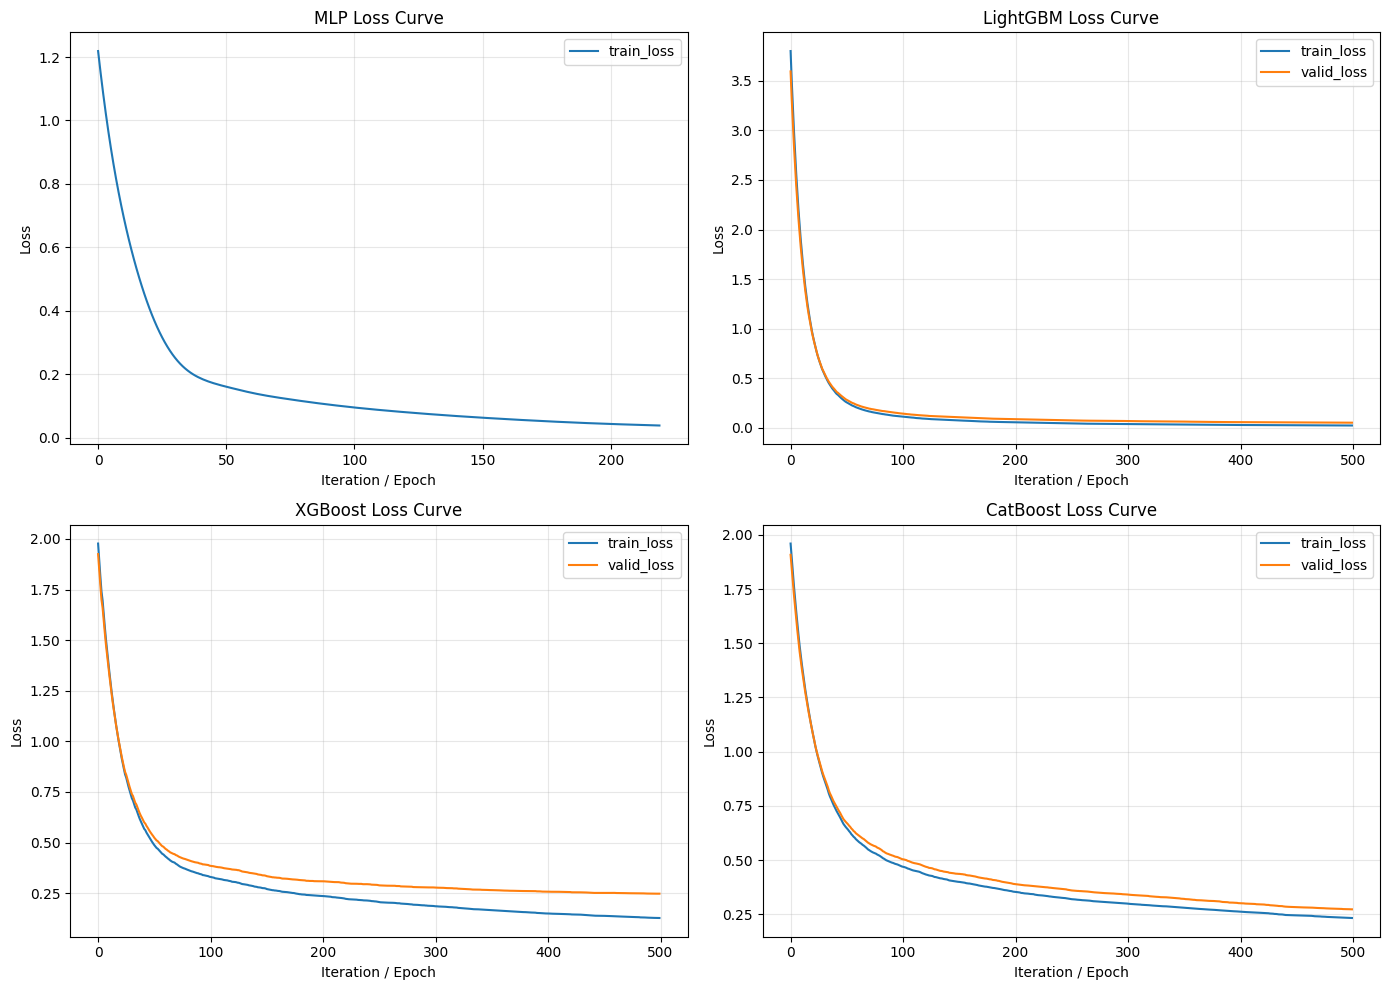

loss figure saved to: /home/user/zpinch10000/ai_xlsx_all_in_training_outputs/fig_training_loss_curves.png
non-iterative models without per-epoch curve = ['PowerLaw', 'Poly2Ridge', 'KNN', 'RandomForest']


In [5]:

# 记录 4 个可迭代模型的训练过程损失，用于画折线图。
loss_history = {}

# 1) MLP：使用项目里手写的两层神经网络，并记录每轮训练损失。
mlp_model = MLP2LayerModel(h1=64, h2=32, lr=1e-3, epochs=220, seed=42)
mlp_model.fit(Xtr, ytr)
loss_history['MLP'] = {
    'train': mlp_model.loss_history_,
}

# 2) LightGBM：同时记录训练集和验证集的 l2 损失。
lgb_eval = {}
lgb_model = LGBMRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    verbose=-1,
)
lgb_model.fit(
    Xtr,
    ytr,
    eval_set=[(Xtr, ytr), (Xva, yva)],
    eval_names=['train', 'valid'],
    callbacks=[lgb.record_evaluation(lgb_eval)],
)
loss_history['LightGBM'] = {
    'train': lgb_eval['train']['l2'],
    'valid': lgb_eval['valid']['l2'],
}

# 3) XGBoost：记录训练集和验证集的 rmse 曲线。
xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(
    Xtr,
    ytr,
    eval_set=[(Xtr, ytr), (Xva, yva)],
    verbose=False,
)
xgb_eval = xgb_model.evals_result()
loss_history['XGBoost'] = {
    'train': xgb_eval['validation_0']['rmse'],
    'valid': xgb_eval['validation_1']['rmse'],
}

# 4) CatBoost：记录训练集和验证集的 RMSE 曲线。
cat_model = CatBoostRegressor(
    random_seed=42,
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False,
)
cat_model.fit(
    Xtr,
    ytr,
    eval_set=(Xva, yva),
    use_best_model=False,
    verbose=False,
)
cat_eval = cat_model.get_evals_result()
loss_history['CatBoost'] = {
    'train': cat_eval['learn']['RMSE'],
    'valid': cat_eval['validation']['RMSE'],
}

# 用 2x2 子图将 4 个模型的损失曲线画到同一张图中。
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, (name, hist) in zip(axes, loss_history.items()):
    ax.plot(hist['train'], label='train_loss')
    if 'valid' in hist:
        ax.plot(hist['valid'], label='valid_loss')
    ax.set_title(f'{name} Loss Curve')
    ax.set_xlabel('Iteration / Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
loss_fig_path = OUTPUT_DIR / 'fig_training_loss_curves.png'
plt.savefig(loss_fig_path, dpi=160)
plt.show()

print('loss figure saved to:', loss_fig_path)
print('non-iterative models without per-epoch curve =', ['PowerLaw', 'Poly2Ridge', 'KNN', 'RandomForest'])


In [6]:

# 在固定测试集上评估 8 个模型。
# 按项目约定，这里会将 train 和 val 合并后重新训练，再在 test 上统一评测。
final_rows = []

for name, model in build_all_models().items():
    model.fit(X[train_idx], yE[train_idx])
    pred = np.maximum(model.predict(Xte), 1e-12)
    metrics = evaluate_model(yte, pred, mte, vte)
    final_rows.append({
        'model': name,
        **metrics,
    })

final_df = pd.DataFrame(final_rows).sort_values('E_MAE').reset_index(drop=True)
final_csv_path = OUTPUT_DIR / 'combined_fixed_split_metrics_notebook.csv'
final_df.to_csv(final_csv_path, index=False, encoding='utf-8-sig')

print('fixed split metrics saved to:', final_csv_path)
final_df


/home/user/miniconda3/envs/ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


fixed split metrics saved to: /home/user/zpinch10000/ai_xlsx_all_in_training_outputs/combined_fixed_split_metrics_notebook.csv


,model,E_MAE,E_RMSE,E_MAPE_percent,v_MAE,v_MAPE_percent
0,LightGBM,0.112218,0.194406,7.450593,1.123470e+06,3.529229
1,RandomForest,0.116100,0.201227,6.845636,1.025089e+06,3.210107
2,XGBoost,0.120934,0.212238,7.959911,1.226532e+06,3.745772
3,CatBoost,0.156115,0.264210,10.453713,1.545716e+06,4.929552
4,KNN,0.163346,0.289301,10.552116,1.687064e+06,4.920283
5,MLP,0.250171,0.410127,16.720171,2.670288e+06,7.575569
6,Poly2Ridge,0.438855,0.623487,25.027135,4.338733e+06,11.680170
7,PowerLaw,0.657566,0.956242,32.543732,5.554168e+06,15.037624


In [7]:

# 在同一个固定测试集里，再按来源拆成 source / target 子集打分。
# 这里不是重新训练，而是把同一批测试样本按来源分组分别统计指标。
subset_rows = []

source_mask = dte == 'source'
target_mask = dte == 'target'

for name, model in build_all_models().items():
    model.fit(X[train_idx], yE[train_idx])
    pred = np.maximum(model.predict(Xte), 1e-12)

    if source_mask.any():
        source_metrics = evaluate_model(yte[source_mask], pred[source_mask], mte[source_mask], vte[source_mask])
        subset_rows.append({'model': name, 'subset': 'source', **source_metrics})

    if target_mask.any():
        target_metrics = evaluate_model(yte[target_mask], pred[target_mask], mte[target_mask], vte[target_mask])
        subset_rows.append({'model': name, 'subset': 'target', **target_metrics})

subset_df = pd.DataFrame(subset_rows).sort_values(['subset', 'E_MAE']).reset_index(drop=True)
subset_csv_path = OUTPUT_DIR / 'combined_fixed_split_source_target_metrics_notebook.csv'
subset_df.to_csv(subset_csv_path, index=False, encoding='utf-8-sig')

print('subset metrics saved to:', subset_csv_path)
subset_df


/home/user/miniconda3/envs/ai/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


subset metrics saved to: /home/user/zpinch10000/ai_xlsx_all_in_training_outputs/combined_fixed_split_source_target_metrics_notebook.csv


,model,subset,E_MAE,E_RMSE,E_MAPE_percent,v_MAE,v_MAPE_percent
0,RandomForest,source,0.023572,0.053097,0.379186,1.630019e+05,0.190620
1,LightGBM,source,0.045300,0.057861,0.912527,5.300432e+05,0.456303
2,XGBoost,source,0.046805,0.063599,0.941713,6.234947e+05,0.470936
3,CatBoost,source,0.054788,0.069563,1.077518,6.273692e+05,0.538560
4,KNN,source,0.104337,0.166788,2.094939,1.419877e+06,1.044982
5,MLP,source,0.186843,0.262826,3.823875,2.567244e+06,1.917845
6,PowerLaw,source,0.244773,0.309333,4.513599,2.266039e+06,2.293911
7,Poly2Ridge,source,0.287370,0.409806,5.410404,3.599267e+06,2.715873
8,LightGBM,target,0.134253,0.221667,9.603500,1.318878e+06,4.541106
9,XGBoost,target,0.145344,0.241962,10.270920,1.425105e+06,4.824136


In [8]:
# 读取主脚本之前保存的完整 summary_metrics.json，便于把 Notebook 固定测试结果和全量汇总结果对应起来。
summary_path = OUTPUT_DIR / 'summary_metrics.json'
with open(summary_path, 'r', encoding='utf-8') as f:
    summary = json.load(f)

print('summary file =', summary_path)
print('available models in script summary =', summary['available_models'])
print('best model from script summary =', summary['best_model_name'])
print()
print('combined_random_split_summary:')
pd.DataFrame(summary['combined_random_split_summary']).T.sort_values('E_MAE')


summary file = /home/user/zpinch10000/ai_xlsx_all_in_training_outputs/summary_metrics.json
available models in script summary = ['CatBoost', 'LightGBM', 'RandomForest', 'XGBoost']
best model from script summary = RandomForest

combined_random_split_summary:


,E_MAE,E_RMSE,E_MAPE_percent,v_MAE,v_MAPE_percent
RandomForest,0.116365,0.208482,7.134709,1.048144e+06,3.311302
LightGBM,0.117564,0.212706,7.946685,1.181757e+06,3.726410
XGBoost,0.124263,0.226594,8.392193,1.270171e+06,3.918031
CatBoost,0.161548,0.281098,10.763876,1.603638e+06,5.026445



## 结果怎么读

这份 Notebook 里有两种“最优”的说法，需要分开看：

### 1. 按单次固定测试集看

- `E_MAE` 最小的是 `LightGBM`
- `E_MAPE` 最小的是 `RandomForest`

这不矛盾，因为：
- `MAE` 看绝对误差
- `MAPE` 看相对误差
- 同一个模型不一定在所有指标上都同时第一

### 2. 按主脚本汇总结果看

主脚本的 `summary_metrics.json` 主要是更稳定的汇总口径，尤其是随机划分平均结果。那里面 `RandomForest` 仍然是总体最稳的模型。

### 3. source / target 子集怎么看

- `source` 子集：原来“对应优化质量”那部分数据
- `target` 子集：原来“丝阵质量20_30_40mgcm”那部分数据

如果某个模型在 `source` 上很好、在 `target` 上明显变差，说明它更擅长老分布，不一定真正学好了新增的质量维度。

### 4. 新数据到底补充了什么

新增的 `20/30/40 mg/cm` 数据，最大的价值不是简单“样本更多”，而是：
- 让同一工况下出现多个质量点
- 让模型第一次真正看到“质量变化时，动能怎么变”
- 让低动能区域也被覆盖进来

所以它主要补充的是：
- 目标域内插值能力
- 质量维度的可学习性

它没有完全解决的是：
- 对未见质量值的强外推能力
- 对未见工况整组留出的强泛化能力
